# 📊 E-commerce Customer Behavior Analysis

## 🔍 Key Findings

### 1. Discount Strategy
Customers who used discounts had LOWER average spending (~787) compared to those who did not (~903).

👉 Insight: Discounts may be attracting low-value customers instead of increasing revenue.

---

### 2. Customer Segmentation
Customers were divided into Low, Medium, High value groups.

👉 High-value users purchase more frequently (lowest days since last purchase ~17 days).

---

### 3. Customer Retention
Low-value users have the longest inactivity (~32 days).

👉 Insight: They are more likely to churn.

---

### 4. Satisfaction Impact
Satisfied customers spend significantly more (~1280) than unsatisfied (~595).

👉 Insight: Improving satisfaction directly boosts revenue.

---

### 5. City Analysis
San Francisco and New York customers spend the most.

👉 Insight: Target high-value cities for marketing.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/uom190346a/e-commerce-customer-behavior-dataset/E-commerce Customer Behavior - Sheet1.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/uom190346a/e-commerce-customer-behavior-dataset/E-commerce Customer Behavior - Sheet1.csv")

df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [4]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [5]:
df['Total Spend'].describe()

count     350.000000
mean      845.381714
std       362.058695
min       410.800000
25%       502.000000
50%       775.200000
75%      1160.600000
max      1520.100000
Name: Total Spend, dtype: float64

In [6]:
df['user_level'] = pd.qcut(df['Total Spend'], 3, labels=['Low', 'Medium', 'High'])

df['user_level'].value_counts()

user_level
Low       124
High      117
Medium    109
Name: count, dtype: int64

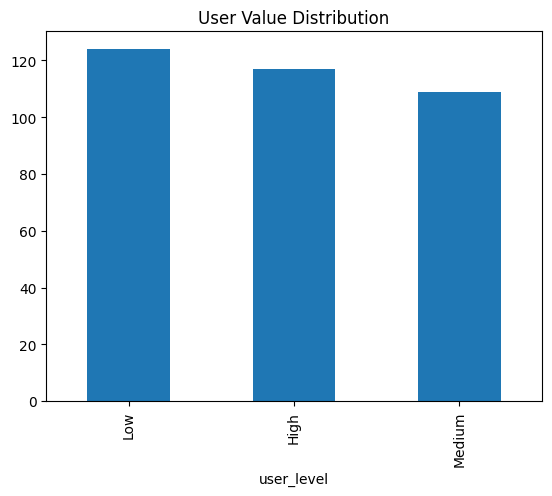

In [7]:
import matplotlib.pyplot as plt

df['user_level'].value_counts().plot(kind='bar')

plt.title("User Value Distribution")
plt.show()

In [8]:
df.groupby('Discount Applied')['Total Spend'].mean()

Discount Applied
False    903.489714
True     787.273714
Name: Total Spend, dtype: float64

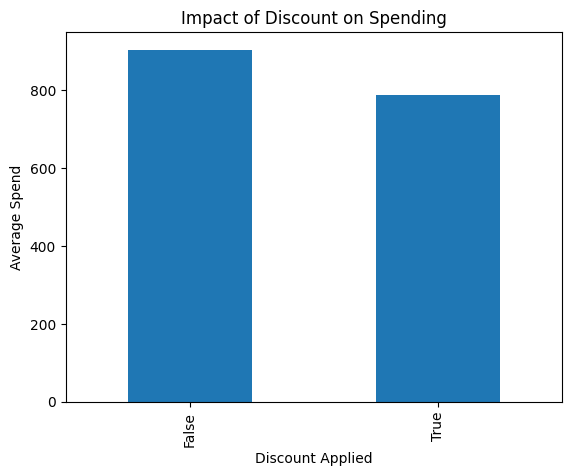

In [9]:
df.groupby('Discount Applied')['Total Spend'].mean().plot(kind='bar')

plt.title("Impact of Discount on Spending")
plt.ylabel("Average Spend")

plt.show()

In [10]:
df.groupby('user_level')['Days Since Last Purchase'].mean()

/tmp/ipykernel_55/420157604.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('user_level')['Days Since Last Purchase'].mean()


user_level
Low       32.056452
Medium    29.651376
High      17.940171
Name: Days Since Last Purchase, dtype: float64

In [11]:
df.groupby('Satisfaction Level')['Total Spend'].mean()

Satisfaction Level
Neutral         616.414019
Satisfied      1280.319200
Unsatisfied     595.136207
Name: Total Spend, dtype: float64

In [12]:
df.groupby('City')['Total Spend'].mean().sort_values(ascending=False)

City
San Francisco    1459.772414
New York         1165.035593
Los Angeles       805.491525
Miami             690.389655
Chicago           499.882759
Houston           446.894828
Name: Total Spend, dtype: float64

In [13]:
df.groupby('Membership Type')['Total Spend'].mean().sort_values(ascending=False)

Membership Type
Gold      1311.144444
Silver     748.432479
Bronze     473.388793
Name: Total Spend, dtype: float64

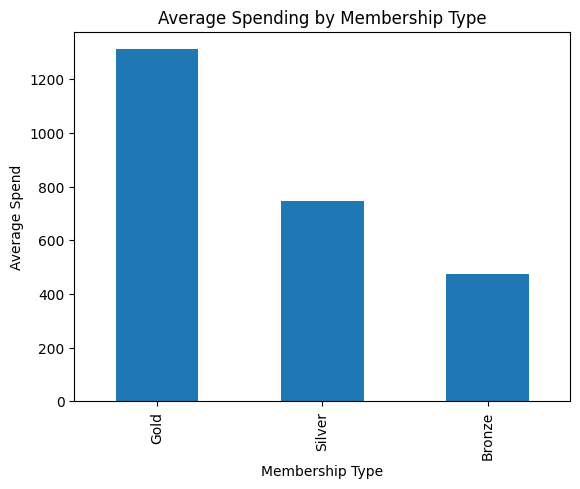

In [14]:
df.groupby('Membership Type')['Total Spend'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Spending by Membership Type")
plt.ylabel("Average Spend")
plt.show()

In [15]:
df['age_group'] = pd.cut(
    df['Age'],
    bins=[25, 30, 35, 40, 45],
    labels=['26-30', '31-35', '36-40', '41-45']
)

df.groupby('age_group')['Total Spend'].mean()

/tmp/ipykernel_55/3485645232.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['Total Spend'].mean()


age_group
26-30    1176.168376
31-35     875.116239
36-40     463.622414
41-45     499.882759
Name: Total Spend, dtype: float64

/tmp/ipykernel_55/2481649120.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['Total Spend'].mean().plot(kind='bar')


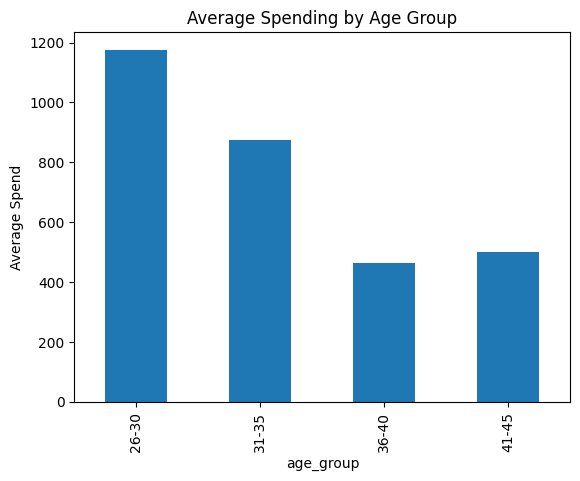

In [16]:
df.groupby('age_group')['Total Spend'].mean().plot(kind='bar')
plt.title("Average Spending by Age Group")
plt.ylabel("Average Spend")
plt.show()

In [17]:
df['churn'] = df['Days Since Last Purchase'].apply(lambda x: 1 if x > 30 else 0)

df['churn'].value_counts()

churn
0    226
1    124
Name: count, dtype: int64

In [18]:
features = [
    'Age',
    'Total Spend',
    'Items Purchased',
    'Average Rating'
]

In [19]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [21]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.9857142857142858

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        51
           1       1.00      0.95      0.97        19

    accuracy                           0.99        70
   macro avg       0.99      0.97      0.98        70
weighted avg       0.99      0.99      0.99        70



<Axes: >

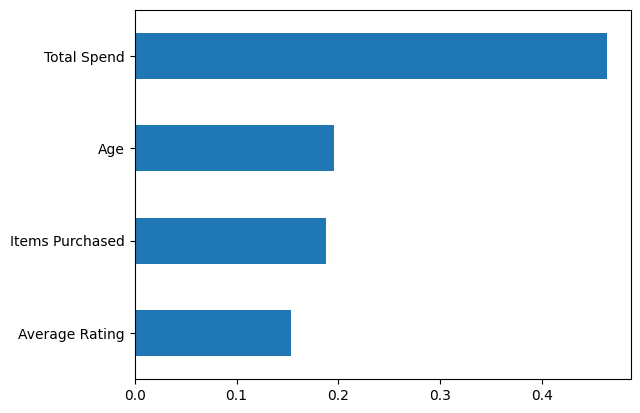

In [23]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')

In [24]:
df_encoded = pd.get_dummies(
    df,
    columns=['Gender', 'City', 'Membership Type'],
    drop_first=True
)

In [25]:
df_encoded.head()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,user_level,age_group,churn,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership Type_Gold,Membership Type_Silver
0,101,29,1120.20,14,4.6,True,25,Satisfied,High,26-30,0,False,False,False,False,True,False,True,False
1,102,34,780.50,11,4.1,False,18,Neutral,Medium,31-35,0,True,False,True,False,False,False,False,True
2,103,43,510.75,9,3.4,True,42,Unsatisfied,Low,41-45,1,False,False,False,False,False,False,False,False
3,104,30,1480.30,19,4.7,False,12,Satisfied,High,26-30,0,True,False,False,False,False,True,True,False
4,105,27,720.40,13,4.0,True,55,Unsatisfied,Medium,26-30,1,True,False,False,True,False,False,False,True


In [26]:
features = df_encoded.drop(columns=[
    'Customer ID',
    'churn',
    'Days Since Last Purchase',
    'Satisfaction Level'
]).columns

In [27]:
X = df_encoded[features]
y = df_encoded['churn']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
import pandas as pd

# 重新做 one-hot 编码
df_model = pd.get_dummies(
    df,
    columns=['Gender', 'City', 'Membership Type', 'user_level', 'age_group'],
    drop_first=True
)

# 删掉不该进模型的列
X = df_model.drop(columns=[
    'Customer ID',
    'churn',
    'Days Since Last Purchase',
    'Satisfaction Level'
], errors='ignore')

y = df_model['churn']

# 检查是否还有非数值列
print(X.dtypes)
print("\n非数值列：")
print(X.select_dtypes(include=['object', 'category']).columns)

Age                         int64
Total Spend               float64
Items Purchased             int64
Average Rating            float64
Discount Applied             bool
Gender_Male                  bool
City_Houston                 bool
City_Los Angeles             bool
City_Miami                   bool
City_New York                bool
City_San Francisco           bool
Membership Type_Gold         bool
Membership Type_Silver       bool
user_level_Medium            bool
user_level_High              bool
age_group_31-35              bool
age_group_36-40              bool
age_group_41-45              bool
dtype: object

非数值列：
Index([], dtype='object')


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LR Accuracy: 0.9857142857142858
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        51
           1       1.00      0.95      0.97        19

    accuracy                           0.99        70
   macro avg       0.99      0.97      0.98        70
weighted avg       0.99      0.99      0.99        70



In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.9857142857142858
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        51
           1       1.00      0.95      0.97        19

    accuracy                           0.99        70
   macro avg       0.99      0.97      0.98        70
weighted avg       0.99      0.99      0.99        70



In [37]:
import numpy as np

df['churn'] = np.where(
    (df['Days Since Last Purchase'] > 30) &
    (df['Average Rating'] < 4),
    1, 0
)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


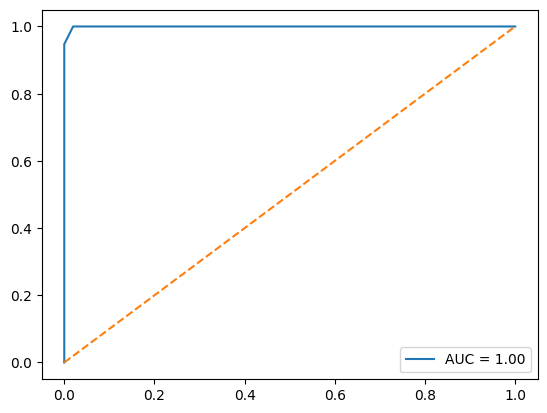

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

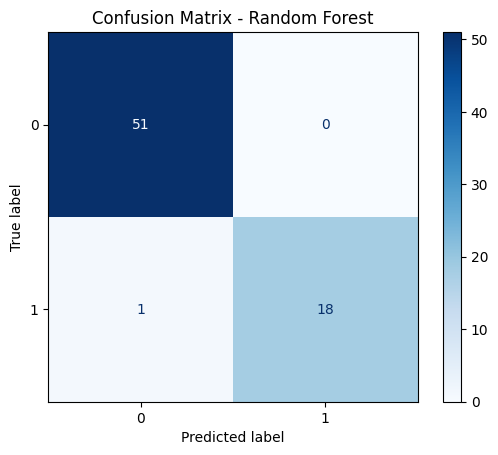

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

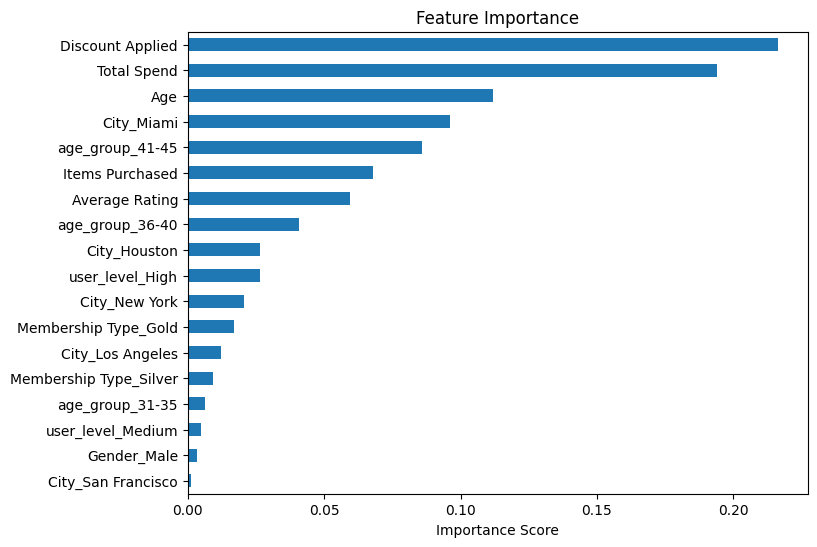

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

## Model Conclusion

- Both Logistic Regression and Random Forest achieved very high performance.
- Total Spend appears to be the most influential factor in churn prediction.
- Since the churn label was rule-based and the dataset is synthetic, the results mainly demonstrate workflow rather than real-world predictive power.